## Carrega base de dados dos clientes

In [1]:
import Iniciar_dados as init_data
import solucaoInicial as init_sol
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
clientes=init_data.ler_dados_csv()
PAs=init_data.inicializar_PAs()
users=init_data.inicializar_users()

## Funções objetivo

In [3]:
##Funções objetivo
def f1_min_distancia(users):
    sum_dist=0

    for user in users:
        if(user.user_atendido):
            sum_dist+= np.linalg.norm(np.array(user.coordenadas) - np.array(user.PA_conectado))
    return sum_dist

def f2_min_pas_ativos(PAs):
    sum_pa=0
    for pa in PAs:
        if(pa.PA_ativado):
            sum_pa+=1
    return sum_pa

## Gerar solução incial

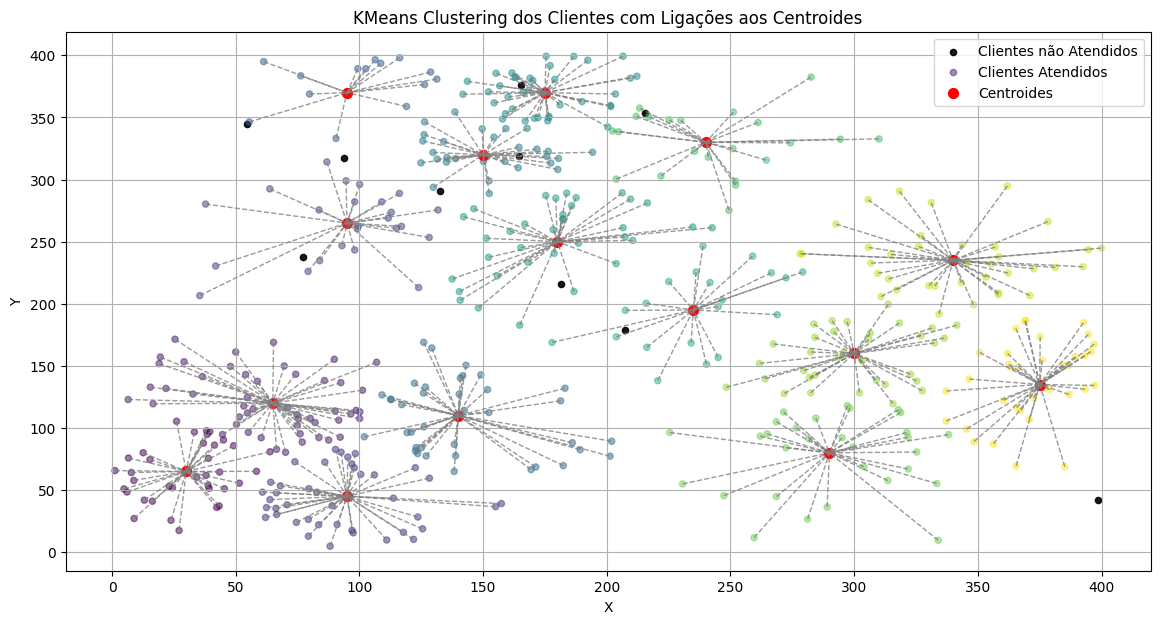

f1 15423.636106852447 f2: 15


In [4]:
inicial_solucao=init_sol.gerar_sol_inicial(15) 
PAs_,users_=init_sol.gerar_resultados(inicial_solucao, PAs, users)
init_sol.visulizar_solucao(PAs_,users_)
print("f1",f1_min_distancia(users_),"f2:",f2_min_pas_ativos(PAs_))

## Algoritmo NSGA-II

Soluções Factíveis:  29
Soluções Infacíveis: 0
Soluções Únicas:     8
Hipervolume da fronteira %: 60.892559026949634


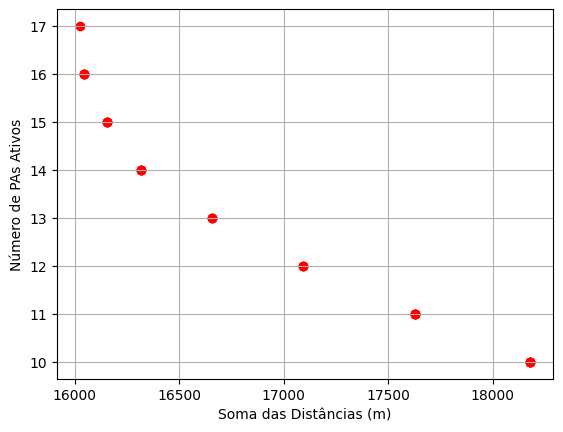

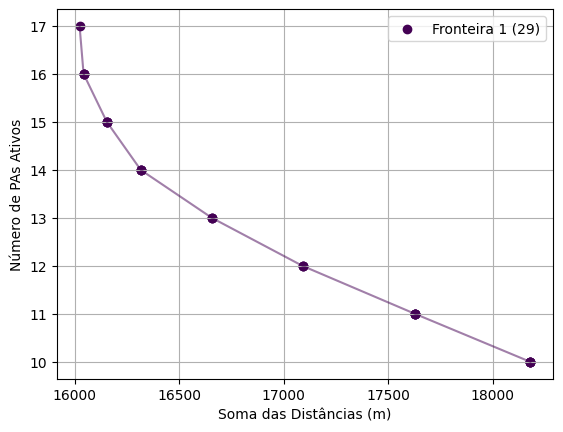

In [5]:
import NSGAII 

n=30
nsg=NSGAII.NSGAII(PAs=PAs, users=users, pop_size=n, max_gen=100)

init=[]
for ip in range(1,n):
    inicial_solucao=init_sol.gerar_sol_inicial(10) 
    init.append(inicial_solucao)
pareto=nsg.run(init)
nsg.visualize_results(pareto_solutions=pareto[0], pareto_objectives=pareto[1])
nsg.visualize_population_fronts(population=pareto[0],objectives=pareto[1])

In [6]:
s = pareto[1]

# Ordena pelo primeiro objetivo (x)
solucoes_ordenadas = sorted(s, key=lambda x: x[0])

# Determina os limites do espaço objetivo
min_f1 = min(p[0] for p in s)
min_f2 = min(p[1] for p in s)
referencia = max(p[0] for p in s), max(p[1] for p in s)

# Inicializa o hipervolume
hipervolume = 0.0
for i, ponto in enumerate(solucoes_ordenadas):
    f1, f2 = ponto
    if i == len(solucoes_ordenadas) - 1:
        largura = referencia[0] - f1
    else:
        proximo_f1 = solucoes_ordenadas[i + 1][0]
        largura = proximo_f1 - f1

    altura = referencia[1] - f2
    
    if largura > 0 and altura > 0:
        hipervolume += largura * altura

# Calcula o hipervolume total possível (área total do espaço objetivo)
hv_total = (referencia[0] - min_f1) * (referencia[1] - min_f2)

# Retorna o hipervolume normalizado
hipervolume / hv_total if hv_total > 0 else 0

0.6089255902694963

In [7]:
nsg.calculate_hypervolume(pareto[1])

60.892559026949634

Soluções Factíveis:  29
Soluções Infacíveis: 0
Soluções Únicas:     8
Hipervolume da fronteira %: 60.892559026949634


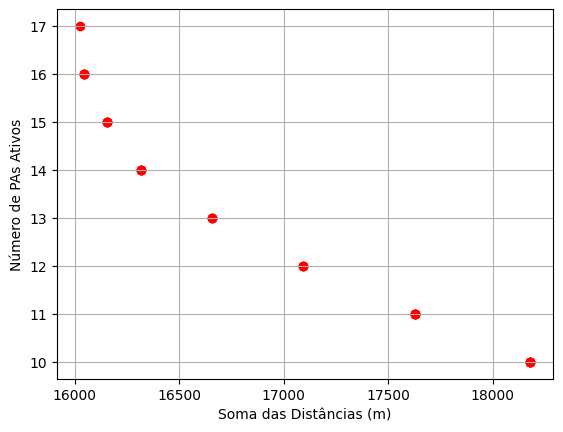

In [8]:
nsg.visualize_results(pareto_solutions=pareto[0], pareto_objectives=pareto[1])

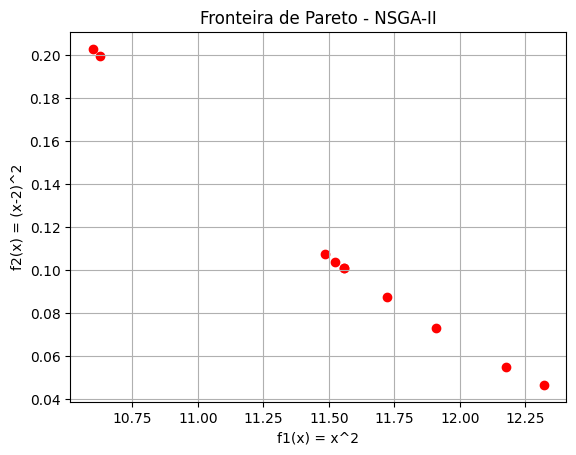

In [9]:
POP_SIZE = 10
MAX_GEN = 100
CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.1
BOUNDS = [0, 3]  # intervalo de busca para x

# Funções objetivo
def evaluate(x):
    f1 = x**2+4*x+2
    f2 = (x - 2)**2
    return [f1, f2]


# Geração inicial
def init_population():
    return [random.uniform(*BOUNDS) for _ in range(POP_SIZE)]


# Domínio de Pareto
def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))


def non_dominated_sort(population, objectives):
    fronts = [[]]
    domination_count = [0] * len(population)
    dominated = [[] for _ in population]
    
    for p in range(len(population)):
        for q in range(len(population)):
            if dominates(objectives[p], objectives[q]):
                dominated[p].append(q)
            elif dominates(objectives[q], objectives[p]):
                domination_count[p] += 1
        if domination_count[p] == 0:
            fronts[0].append(p)
    
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in dominated[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
    
    return fronts[:-1]  # remove último vazio


def crowding_distance(front, objectives):
    distance = [0.0] * len(front)
    for m in range(len(objectives[0])):
        obj_vals = [objectives[i][m] for i in front]
        sorted_indices = np.argsort(obj_vals)
        f_min = obj_vals[sorted_indices[0]]
        f_max = obj_vals[sorted_indices[-1]]
        distance[sorted_indices[0]] = float('inf')
        distance[sorted_indices[-1]] = float('inf')
        for i in range(1, len(front) - 1):
            prev_val = obj_vals[sorted_indices[i - 1]]
            next_val = obj_vals[sorted_indices[i + 1]]
            if f_max - f_min == 0:
                d = 0
            else:
                d = (next_val - prev_val) / (f_max - f_min)
            distance[sorted_indices[i]] += d
    return distance


def tournament_selection(pop, obj, k=2):
    selected = random.sample(range(len(pop)), k)
    best = selected[0]
    for i in selected[1:]:
        if dominates(obj[i], obj[best]):
            best = i
        elif obj[i] == obj[best] and random.random() < 0.5:
            best = i
    return pop[best]


def crossover(p1, p2):
    if random.random() < CROSSOVER_RATE:
        alpha = random.random()
        child = alpha * p1 + (1 - alpha) * p2
        return min(max(child, BOUNDS[0]), BOUNDS[1])
    return p1


def mutate(x):
    if random.random() < MUTATION_RATE:
        delta = np.random.normal(0, 0.1)
        x += delta
        x = min(max(x, BOUNDS[0]), BOUNDS[1])
    return x


# NSGA-II principal
def nsga2():
    population = init_population()

    for generation in range(MAX_GEN):
        objectives = [evaluate(x) for x in population]
        fronts = non_dominated_sort(population, objectives)
        
        new_population = []
        for front in fronts:
            crowding = crowding_distance(front, objectives)
            sorted_front = sorted(zip(front, crowding), key=lambda x: -x[1])
            new_population.extend([population[i] for i, _ in sorted_front])
            if len(new_population) >= POP_SIZE:
                new_population = new_population[:POP_SIZE]
                break

        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_selection(new_population, [evaluate(x) for x in new_population])
            p2 = tournament_selection(new_population, [evaluate(x) for x in new_population])
            child = crossover(p1, p2)
            child = mutate(child)
            offspring.append(child)

        population = offspring

    # Resultado final
    final_objectives = [evaluate(x) for x in population]
    pareto_front = non_dominated_sort(population, final_objectives)[0]
    return [population[i] for i in pareto_front], [final_objectives[i] for i in pareto_front]


# Executar
pareto_solutions, pareto_objectives = nsga2()

# Mostrar
import matplotlib.pyplot as plt

f1_vals, f2_vals = zip(*pareto_objectives)
plt.scatter(f1_vals, f2_vals, color='red')
plt.xlabel("f1(x) = x^2")
plt.ylabel("f2(x) = (x-2)^2")
plt.title("Fronteira de Pareto - NSGA-II")
plt.grid(True)
plt.show()
